In [586]:
import pandas as pd

In [587]:
roles = pd.read_csv("Role_Skill_Matrix.csv")
roles.head()

,Role,Required Skills
0,Web Developement Intern,"Python, HTML, CSS, JavaScript,MySQL,SQL,Java,G..."
1,Data Analytics Intern,"Python, SQL, Data Cleaning, Data Analysis, Dat..."
2,Digital Marketing Intern,"Social Media Marketing, SEO, Content Marketing..."
3,Graphic Design Intern,"Graphic Design, Typography, Color Theory, Bran..."
4,HR/Operations Intern,"Recruitment, Talent Acquisition, Employee Onbo..."


In [588]:
resumes = pd.read_csv("structured resume.csv")
resumes.head()

,Name,Skills
0,Shashank Singh,"python, java, excel, graphic design"
1,Surishetty Harivallabha Sai,"python, html, css, javascript, sql, java, git,..."
2,PREMKUMAR NARAYAN TAMBEKAR,"python, sql, git, excel, power bi, canva, figma"
3,DASARI HARSHINI,"python, c"
4,Suraj Kumar,"python, sql, java, git, github, excel, canva,..."


In [589]:

# Convert skills into list format.

roles["Required Skills"] = roles["Required Skills"].str.lower()
roles["Required Skills"] = roles["Required Skills"].apply(
    lambda x: [skill.strip() for skill in x.split(",")]
)

resumes["Skills"] = resumes["Skills"].str.lower()
resumes["Skills"] = resumes["Skills"].apply(
    lambda x: [skill.strip() for skill in x.split(",")]
)

In [590]:
def calculate_match(candidate_skills, role_skills):
    
    matched = set(candidate_skills)&(set(role_skills))
    
    score = (len(matched) / len(role_skills)) * 100
    
    return round(score,2)
    

In [591]:
results = []

for i, candidate in resumes.iterrows():
    
    name = candidate["Name"]
    skills = candidate["Skills"]
    
    for j, role in roles.iterrows():
        
        role_name = role["Role"]
        role_skills = role["Required Skills"]
        
        score = calculate_match(skills, role_skills)
        
        results.append({
            "Candidate": name,
            "Role": role_name,
            "Score": score
        })

results_df = pd.DataFrame(results)

In [592]:
results_df.head()

,Candidate,Role,Score
0,Shashank Singh,Web Developement Intern,20.0
1,Shashank Singh,Data Analytics Intern,20.0
2,Shashank Singh,Digital Marketing Intern,0.0
3,Shashank Singh,Graphic Design Intern,10.0
4,Shashank Singh,HR/Operations Intern,10.0


In [593]:
pivot_table = results_df.pivot(index="Candidate", columns="Role", values="Score").fillna(0)
pivot_table.reset_index(inplace=True)

pivot_table.head()

Role,Candidate,Data Analytics Intern,Digital Marketing Intern,Graphic Design Intern,HR/Operations Intern,Web Developement Intern
0,DASARI HARSHINI,10.0,0.0,0.0,0.0,10.0
1,AADITYA MEHTA,10.0,0.0,0.0,0.0,80.0
2,AASTHA BAJPAI,20.0,0.0,0.0,0.0,100.0
3,AASTHA VINOD,10.0,0.0,0.0,20.0,0.0
4,AAYUSH KUMAR CHAURASIA,30.0,0.0,0.0,10.0,60.0


In [594]:
role_columns = pivot_table.columns[1:]
# Find best Role
pivot_table["Best Role"] = pivot_table[role_columns].idxmax(axis=1)

In [595]:
# Finde Best Score
pivot_table["Best Score"] = pivot_table[role_columns].max(axis=1)


In [596]:
def fit_category(score):
    if score >= 70:
        return "High Fit"
    elif score >= 40:
        return "Medium Fit"
    else:
        return "Low Fit"

pivot_table["Fit Category"] = pivot_table["Best Score"].apply(fit_category)

In [597]:
pivot_table.head()

Role,Candidate,Data Analytics Intern,Digital Marketing Intern,Graphic Design Intern,HR/Operations Intern,Web Developement Intern,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,10.0,0.0,0.0,0.0,10.0,Data Analytics Intern,10.0,Low Fit
1,AADITYA MEHTA,10.0,0.0,0.0,0.0,80.0,Web Developement Intern,80.0,High Fit
2,AASTHA BAJPAI,20.0,0.0,0.0,0.0,100.0,Web Developement Intern,100.0,High Fit
3,AASTHA VINOD,10.0,0.0,0.0,20.0,0.0,HR/Operations Intern,20.0,Low Fit
4,AAYUSH KUMAR CHAURASIA,30.0,0.0,0.0,10.0,60.0,Web Developement Intern,60.0,Medium Fit


In [598]:
pivot_table = pivot_table.merge(
    resumes[["Name", "Skills"]],
    left_on="Candidate",
    right_on="Name",
    how="left"
)

In [599]:
summary_table = pivot_table[
    ["Candidate", "Skills", "Best Role", "Best Score", "Fit Category"]
]

summary_table.head()

,Candidate,Skills,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,"[python, c]",Data Analytics Intern,10.0,Low Fit
1,AADITYA MEHTA,"[html, css, javascript, mysql, sql, java, git,...",Web Developement Intern,80.0,High Fit
2,AASTHA BAJPAI,"[python, html, css, javascript, mysql, sql, ja...",Web Developement Intern,100.0,High Fit
3,AASTHA VINOD,"[excel, word]",HR/Operations Intern,20.0,Low Fit
4,AAYUSH KUMAR CHAURASIA,"[python, html, css, javascript, sql, java, excel]",Web Developement Intern,60.0,Medium Fit


In [600]:
summary_table.to_excel("Role_based_matching.xlsx", index=False)

# EDA

In [601]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [602]:
df = pd.read_excel('Role_based_matching.xlsx')

In [603]:
df.head()

,Candidate,Skills,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,"['python', 'c']",Data Analytics Intern,10,Low Fit
1,AADITYA MEHTA,"['html', 'css', 'javascript', 'mysql', 'sql', ...",Web Developement Intern,80,High Fit
2,AASTHA BAJPAI,"['python', 'html', 'css', 'javascript', 'mysql...",Web Developement Intern,100,High Fit
3,AASTHA VINOD,"['excel', 'word']",HR/Operations Intern,20,Low Fit
4,AAYUSH KUMAR CHAURASIA,"['python', 'html', 'css', 'javascript', 'sql',...",Web Developement Intern,60,Medium Fit


In [604]:
df.shape

(184, 5)

In [605]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Candidate     184 non-null    object
 1   Skills        184 non-null    object
 2   Best Role     184 non-null    object
 3   Best Score    184 non-null    int64 
 4   Fit Category  184 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.3+ KB


In [606]:
df.describe()

,Best Score
count,184.000000
mean,54.728261
std,26.196652
min,10.000000
25%,30.000000
50%,60.000000
75%,80.000000
max,100.000000


In [607]:
df.isnull().sum()

Candidate       0
Skills          0
Best Role       0
Best Score      0
Fit Category    0
dtype: int64

In [608]:
df.columns

Index(['Candidate', 'Skills', 'Best Role', 'Best Score', 'Fit Category'], dtype='object')

<Axes: xlabel='Best Score', ylabel='count'>

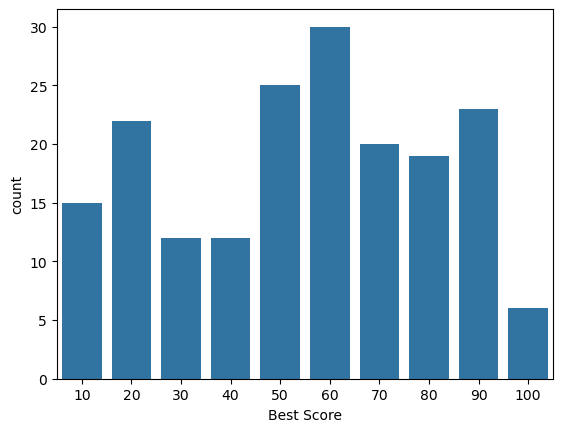

In [609]:
sns.countplot(x=df['Best Score'])

<Axes: xlabel='count', ylabel='Best Role'>

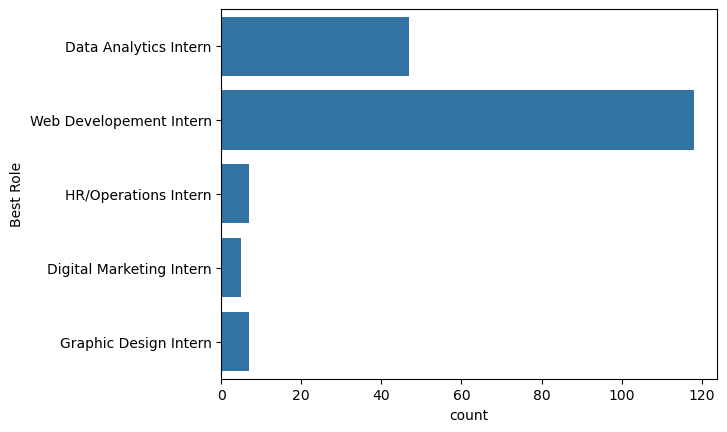

In [610]:
sns.countplot(df['Best Role'])

<Axes: xlabel='count', ylabel='Fit Category'>

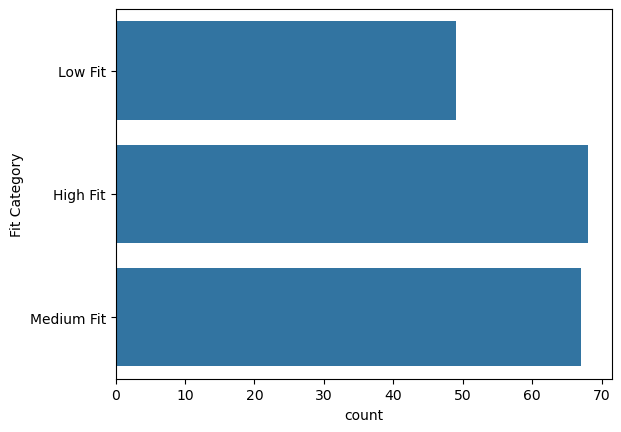

In [611]:
sns.countplot(df['Fit Category'])

# Data cleaning and Processing

In [612]:
df.head()

,Candidate,Skills,Best Role,Best Score,Fit Category
0,DASARI HARSHINI,"['python', 'c']",Data Analytics Intern,10,Low Fit
1,AADITYA MEHTA,"['html', 'css', 'javascript', 'mysql', 'sql', ...",Web Developement Intern,80,High Fit
2,AASTHA BAJPAI,"['python', 'html', 'css', 'javascript', 'mysql...",Web Developement Intern,100,High Fit
3,AASTHA VINOD,"['excel', 'word']",HR/Operations Intern,20,Low Fit
4,AAYUSH KUMAR CHAURASIA,"['python', 'html', 'css', 'javascript', 'sql',...",Web Developement Intern,60,Medium Fit


In [613]:
df.drop_duplicates(inplace=True)

In [614]:
df.shape

(184, 5)

In [615]:
df.dtypes

Candidate       object
Skills          object
Best Role       object
Best Score       int64
Fit Category    object
dtype: object

In [616]:
df['Best Role'].value_counts()

Best Role
Web Developement Intern     118
Data Analytics Intern        47
HR/Operations Intern          7
Graphic Design Intern         7
Digital Marketing Intern      5
Name: count, dtype: int64

In [617]:
print(type(df['Skills'][0]))

<class 'str'>


In [618]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

df['Skills'] = df['Skills'].apply(lambda x: x.split(','))
mlb = MultiLabelBinarizer()

skills_binary = pd.DataFrame(
    mlb.fit_transform(df['Skills']),
    columns=mlb.classes_
)

In [619]:
df_final = pd.concat([df, skills_binary], axis=1)

df_final.drop('Skills', axis=1, inplace=True)

In [620]:
from sklearn.preprocessing import LabelEncoder

le_role = LabelEncoder()

df_final['Best Role'] = le_role.fit_transform(df_final['Best Role'])

In [621]:
le_fit = LabelEncoder()

df_final['Fit Category'] = le_fit.fit_transform(df_final['Fit Category'])

In [622]:
df_final.head()

,Candidate,Best Role,Best Score,Fit Category,'',''],'ai','branding','branding'],'c'],...,['git',['git'],['graphic design',['html',['javascript',['mysql',['powerpoint',['python',['python'],['sql'
0,DASARI HARSHINI,0,10,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,AADITYA MEHTA,4,80,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,AASTHA BAJPAI,4,100,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,AASTHA VINOD,3,20,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AAYUSH KUMAR CHAURASIA,4,60,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [623]:
X = df_final.drop(['Candidate', 'Best Role', 'Best Score','Fit Category'], axis=1)
y = df_final['Best Role']

In [624]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (147, 77)
Testing data: (37, 77)


In [625]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

In [626]:
results = []

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, predictions)
    
    results.append([name, acc])
    
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.8108108108108109
Decision Tree Accuracy: 0.8108108108108109
Random Forest Accuracy: 0.8108108108108109


In [627]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Logistic Regression,0.810811
1,Decision Tree,0.810811
2,Random Forest,0.810811


In [628]:
best_model = results_df.loc[results_df["Accuracy"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: Logistic Regression
Best Accuracy: 0.8108108108108109


In [629]:
final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


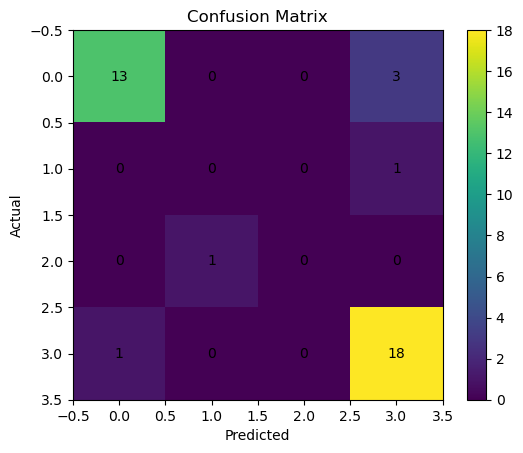

In [630]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# Add values inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

In [631]:
df_final['Predicted Role'] = model.predict(X)

In [632]:
role_mapping = {
    0: "Data Analyst",
    1: "Digital Marketing",
    2: "Graphic Design",
    3: "HR/Operations",
    4: "Web Development"
}
df_final['Best Role'] = df_final['Best Role'].map(role_mapping)
df_final['Predicted Role'] = df_final['Predicted Role'].map(role_mapping)


def get_fit_category(score):
    if score >= 70:
        return "High Fit"
    elif score >= 40:
        return "Medium Fit"
    else:
        return "Low Fit"

df_final['Fit Category'] = df_final['Best Score'].apply(get_fit_category)



In [633]:
df_final = df_final.merge(
    resumes[['Name', 'Skills']],
    left_on='Candidate',
    right_on='Name',
    how='left'
)

In [634]:
df_final['Skills'] = df_final['Skills'].apply(
    lambda x: ", ".join([i.capitalize() for i in x]) if isinstance(x, list) else x
)

In [635]:
df_final.drop('Name', axis=1, inplace=True)

In [636]:
df_final[['Candidate','Skills','Best Role','Best Score','Fit Category','Predicted Role']].head()

,Candidate,Skills,Best Role,Best Score,Fit Category,Predicted Role
0,DASARI HARSHINI,"Python, C",Data Analyst,10,Low Fit,Data Analyst
1,AADITYA MEHTA,"Html, Css, Javascript, Mysql, Sql, Java, Git, ...",Web Development,80,High Fit,Web Development
2,AASTHA BAJPAI,"Python, Html, Css, Javascript, Mysql, Sql, Jav...",Web Development,100,High Fit,Web Development
3,AASTHA VINOD,"Excel, Word",HR/Operations,20,Low Fit,HR/Operations
4,AAYUSH KUMAR CHAURASIA,"Python, Html, Css, Javascript, Sql, Java, Excel",Web Development,60,Medium Fit,Web Development


In [637]:
import joblib
joblib.dump(model, 'resume_model.joblib')
joblib.dump(le_role, 'role_encoder.joblib')
joblib.dump(le_fit, 'fit_encoder.joblib')
joblib.dump(X.columns, 'features.joblib')

['features.joblib']